Limpando diretório existente: eeg_spectrograms_yolo_500ms

Iniciando a geração de spectrograms para o formato YOLO...

--- Processando com Janela de 500ms (nperseg=80, noverlap=60) ---


Processando Sujeitos: 100%|██████████| 100/100 [00:03<00:00, 25.04it/s]



Processamento concluído. Dataset para YOLO salvo em: 'eeg_spectrograms_yolo_500ms'

Exibindo 5 imagens de amostra para cada classe...


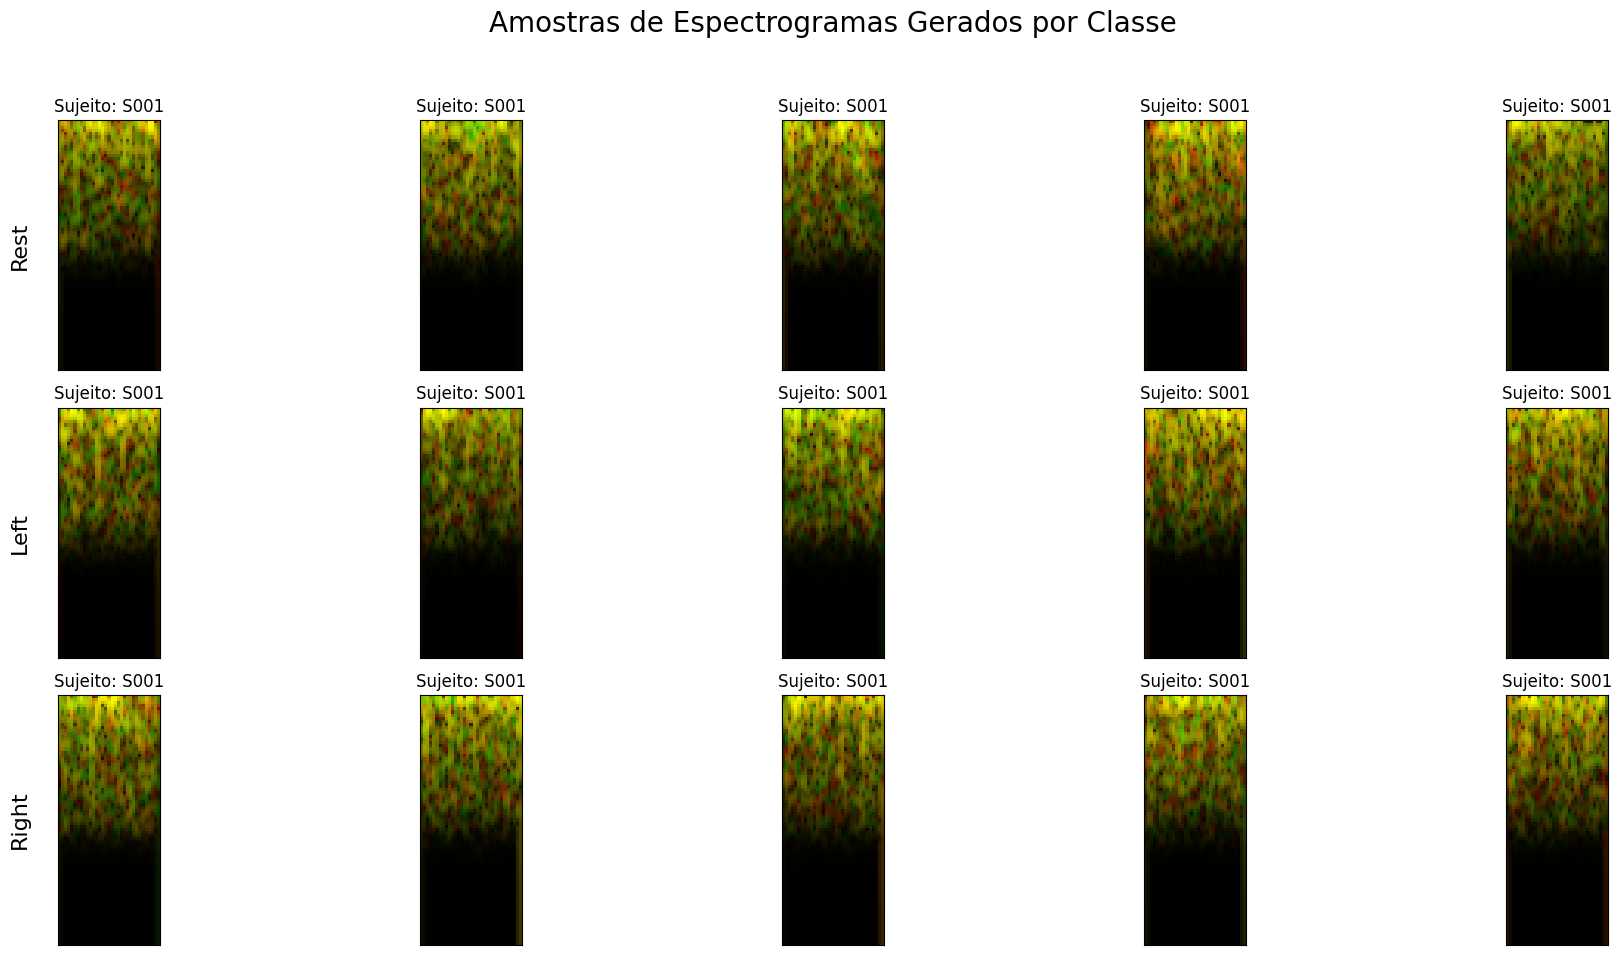

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from pyedflib import EdfReader
from pathlib import Path
import os
import cv2
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --- Funções de Processamento de Dados (Mantidas) ---
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    b, a = signal.iirnotch(notch_freq, quality, fs=fs)
    return filtfilt(b, a, data)

def compute_individual_epoch_stft(data, events, event_type, tmin, tmax, fs,
                                  nperseg, noverlap, nfft):
    event_samples = [e[0] for e in events if e[2] == event_type]
    individual_stft_data = []
    for i, sample in enumerate(event_samples):
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)

        # ### VERIFICAÇÃO DE SEGURANÇA ADICIONADA ###
        # Se o início da janela for antes do início do sinal (índice negativo), pule esta época.
        if start < 0:
            continue
        # Se o fim da janela for além do fim do sinal, pule também.
        if end > len(data):
            continue
        
        epoch = data[start:end]
        if len(epoch) < nperseg:
            continue
            
        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                                nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        individual_stft_data.append({'epoch_idx': i, 'frequencies': f, 'times': t, 'magnitude': np.abs(Zxx)})
    return individual_stft_data

def save_spectrograms_as_image(c3_magnitude, c4_magnitude, output_path):
    if c3_magnitude.size == 0 or c4_magnitude.size == 0:
        return None
    log_c3 = np.log1p(c3_magnitude)
    log_c4 = np.log1p(c4_magnitude)
    norm_c3 = cv2.normalize(log_c3, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    norm_c4 = cv2.normalize(log_c4, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    blue_channel = np.zeros_like(norm_c3)
    bgr_image = cv2.merge([blue_channel, norm_c4, norm_c3])
    cv2.imwrite(output_path, bgr_image)
    return bgr_image

# --- Configurações Globais ---
pasta_raiz_sujeitos = Path('data/physionet_data') 
start_subject = 1
end_subject = 100
registros = ['R04', 'R08', 'R12']
event_dict = {'T0': 'rest', 'T1': 'left', 'T2': 'right'}
epoch_duration_sec = 4
fs = 160
window_durations_ms = [500]

base_output_data_dir = f"eeg_spectrograms_yolo_{window_durations_ms[0]}ms"

if os.path.exists(base_output_data_dir):
    print(f"Limpando diretório existente: {base_output_data_dir}")
    shutil.rmtree(base_output_data_dir)

all_subject_ids = [f'S{i:03d}' for i in range(start_subject, end_subject + 1)]
train_subjects, val_subjects = train_test_split(all_subject_ids, test_size=0.2, random_state=42)

for split in ['train', 'val']:
    for class_name in event_dict.values():
        os.makedirs(os.path.join(base_output_data_dir, split, class_name), exist_ok=True)

print("\nIniciando a geração de spectrograms para o formato YOLO...")

# --- ### MODIFICADO PARA VISUALIZAÇÃO POR CLASSE ### ---
# Dicionário para armazenar as imagens de cada classe
images_to_display = {class_name: [] for class_name in event_dict.values()}
num_per_class = 5
# -------------------------------------------------------

# --- Loop Principal para Processamento ---
for current_window_ms in window_durations_ms:
    current_window_s = current_window_ms / 1000.0
    nperseg = int(fs * current_window_s)
    noverlap = int(nperseg * 0.75) 
    nfft = nperseg * 2
    nperseg = max(1, nperseg)
    noverlap = min(noverlap, nperseg - 1)

    print(f"\n--- Processando com Janela de {current_window_ms}ms (nperseg={nperseg}, noverlap={noverlap}) ---")

    for subject_id in tqdm(all_subject_ids, desc="Processando Sujeitos"):
        subject_folder_path = pasta_raiz_sujeitos / subject_id
        if not subject_folder_path.is_dir():
            continue

        split_folder = 'train' if subject_id in train_subjects else 'val'

        for registro in registros:
            edf_file = next(subject_folder_path.glob(f'*{registro}.edf'), None)
            if not edf_file:
                continue
            
            try:
                reader = EdfReader(str(edf_file))
                signal_labels = reader.getSignalLabels()
                c3_idx = signal_labels.index('C3..')
                c4_idx = signal_labels.index('C4..')
                c3_signal = reader.readSignal(c3_idx)
                c4_signal = reader.readSignal(c4_idx)
                annotations_onset, _, annotations_description = reader.readAnnotations()
                reader.close()
                
                events = [[int(onset * fs), 0, desc] for onset, desc in zip(annotations_onset, annotations_description)]
                c3_filtered = notch_filter(bandpass_filter(c3_signal, 0.5, 40, fs), 60, fs)
                c4_filtered = notch_filter(bandpass_filter(c4_signal, 0.5, 40, fs), 60, fs)
                
                conditions = ['T0', 'T1', 'T2']
                for cond_key in conditions:
                    class_name = event_dict[cond_key]
                    
                    # --- DEPOIS (SOLUÇÃO) ---
                    # Define o início 2s ANTES do marcador e o fim 2s DEPOIS
                    t_start = -2.0 
                    t_end = 2.0
                    # A duração total continua sendo t_end - t_start = 4 segundos

                    c3_epoch_data = compute_individual_epoch_stft(c3_filtered, events, cond_key, tmin=t_start, tmax=t_end, fs=fs, ...)
                    c4_epoch_data = compute_individual_epoch_stft(c4_filtered, events, cond_key, tmin=t_start, tmax=t_end, fs=fs, ...)

                    for j in range(len(c3_epoch_data)):
                        # --- ### MODIFICADO PARA VISUALIZAÇÃO POR CLASSE ### ---
                        # Se já coletamos 5 imagens para esta classe, podemos pular o resto
                        if len(images_to_display[class_name]) >= num_per_class:
                            continue
                        # -------------------------------------------------------

                        Zxx_c3 = c3_epoch_data[j]['magnitude']
                        Zxx_c4 = c4_epoch_data[j]['magnitude']
                        
                        if Zxx_c3 is not None and Zxx_c4 is not None:
                            epoch_idx = c3_epoch_data[j]['epoch_idx']
                            base_filename = f"{subject_id}_{edf_file.stem.replace('.', '_')}_epoch_{epoch_idx+1}.png"
                            output_path = os.path.join(base_output_data_dir, split_folder, class_name, base_filename)
                            
                            saved_image = save_spectrograms_as_image(Zxx_c3, Zxx_c4, output_path)

                            # --- ### MODIFICADO PARA VISUALIZAÇÃO POR CLASSE ### ---
                            if saved_image is not None and len(images_to_display[class_name]) < num_per_class:
                                rgb_image = cv2.cvtColor(saved_image, cv2.COLOR_BGR2RGB)
                                title = f"Sujeito: {subject_id}"
                                images_to_display[class_name].append({'image': rgb_image, 'title': title})
                            # -------------------------------------------------------
            except Exception:
                if 'reader' in locals() and reader.isOpen():
                    reader.close()
                continue

print(f"\nProcessamento concluído. Dataset para YOLO salvo em: '{base_output_data_dir}'")

# --- ### MODIFICADO PARA VISUALIZAÇÃO POR CLASSE ### ---
# Ao final, exibe as imagens coletadas em uma grade 3x5
print("\nExibindo 5 imagens de amostra para cada classe...")

# Define a ordem das classes para a plotagem
class_order = ['rest', 'left', 'right']
num_classes = len(class_order)

# Cria uma figura com 3 linhas e 5 colunas
fig, axes = plt.subplots(nrows=num_classes, ncols=num_per_class, figsize=(20, 10))
fig.suptitle("Amostras de Espectrogramas Gerados por Classe", fontsize=20)

for row_idx, class_name in enumerate(class_order):
    # Pega a lista de imagens para a classe atual
    image_list = images_to_display[class_name]
    
    # Define o nome da classe como o título da linha
    axes[row_idx, 0].set_ylabel(class_name.capitalize(), fontsize=16, rotation=90, labelpad=20)
    
    for col_idx in range(num_per_class):
        ax = axes[row_idx, col_idx]
        if col_idx < len(image_list):
            # Se tivermos uma imagem para esta posição, mostre-a
            item = image_list[col_idx]
            ax.imshow(item['image'])
            ax.set_title(item['title'])
        # Esconde os eixos para uma visualização mais limpa
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para caber o supertítulo
plt.show()
# -------------------------------------------------------


Iniciando a geração de spectrograms para o formato YOLO (com janelas centralizadas)...

--- Processando com Janela de 500ms (nperseg=80, noverlap=60) ---


Processando Sujeitos: 100%|██████████| 100/100 [00:09<00:00, 10.96it/s]



Processamento concluído. Dataset para YOLO salvo em: 'eeg_spectrograms_yolo_500ms_centered'

Exibindo 5 imagens de amostra para cada classe...


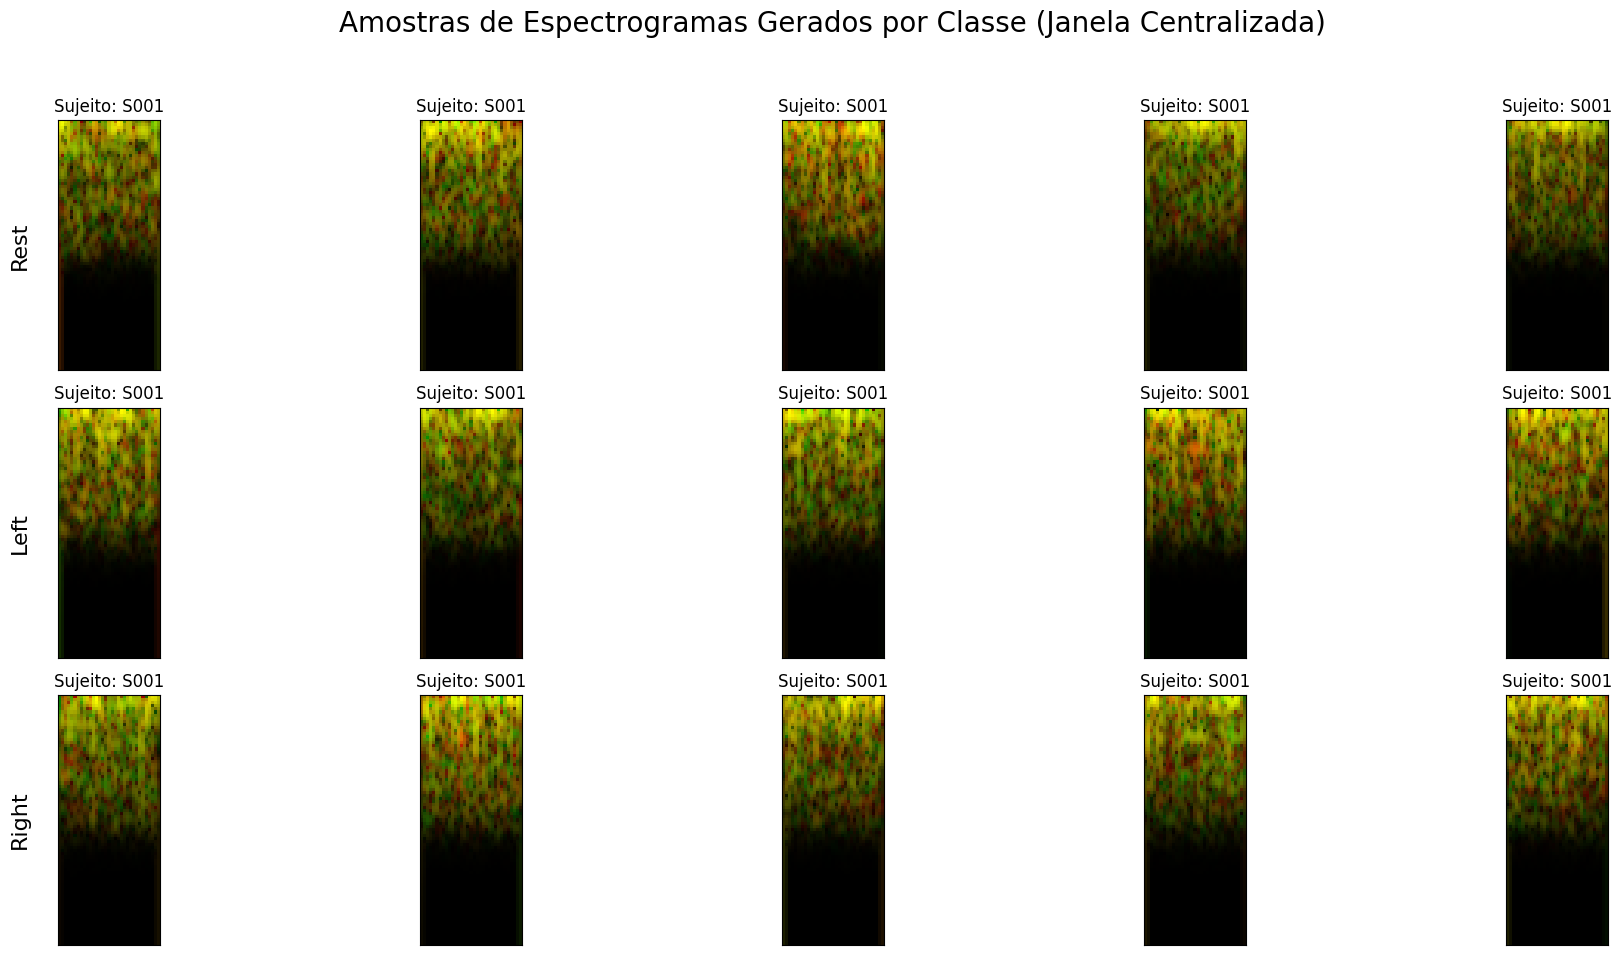

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from pyedflib import EdfReader
from pathlib import Path
import os
import cv2
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --- Funções de Processamento de Dados ---
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    b, a = signal.iirnotch(notch_freq, quality, fs=fs)
    return filtfilt(b, a, data)

# --- ### FUNÇÃO ATUALIZADA ### ---
# A função agora inclui verificações de segurança para tmin negativo.
def compute_individual_epoch_stft(data, events, event_type, tmin, tmax, fs,
                                  nperseg, noverlap, nfft):
    event_samples = [e[0] for e in events if e[2] == event_type]
    individual_stft_data = []
    for i, sample in enumerate(event_samples):
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)

        # Verificação de segurança para evitar índices inválidos
        if start < 0 or end > len(data):
            continue
        
        epoch = data[start:end]
        if len(epoch) < nperseg:
            continue
            
        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                                nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        individual_stft_data.append({'epoch_idx': i, 'frequencies': f, 'times': t, 'magnitude': np.abs(Zxx)})
    return individual_stft_data

def save_spectrograms_as_image(c3_magnitude, c4_magnitude, output_path):
    if c3_magnitude.size == 0 or c4_magnitude.size == 0:
        return None
    log_c3 = np.log1p(c3_magnitude)
    log_c4 = np.log1p(c4_magnitude)
    norm_c3 = cv2.normalize(log_c3, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    norm_c4 = cv2.normalize(log_c4, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    blue_channel = np.zeros_like(norm_c3)
    bgr_image = cv2.merge([blue_channel, norm_c4, norm_c3])
    cv2.imwrite(output_path, bgr_image)
    return bgr_image

# --- Configurações Globais ---
pasta_raiz_sujeitos = Path('data/physionet_data') 
start_subject = 1
end_subject = 100
registros = ['R04', 'R08', 'R12']
event_dict = {'T0': 'rest', 'T1': 'left', 'T2': 'right'}
# A duração da época agora é definida por t_start e t_end, mas mantemos a variável para referência.
epoch_duration_sec = 4 
fs = 160
window_durations_ms = [500]

base_output_data_dir = f"eeg_spectrograms_yolo_{window_durations_ms[0]}ms_centered" # Nome atualizado para refletir a mudança

if os.path.exists(base_output_data_dir):
    print(f"Limpando diretório existente: {base_output_data_dir}")
    shutil.rmtree(base_output_data_dir)

all_subject_ids = [f'S{i:03d}' for i in range(start_subject, end_subject + 1)]
train_subjects, val_subjects = train_test_split(all_subject_ids, test_size=0.2, random_state=42)

for split in ['train', 'val']:
    for class_name in event_dict.values():
        os.makedirs(os.path.join(base_output_data_dir, split, class_name), exist_ok=True)

print("\nIniciando a geração de spectrograms para o formato YOLO (com janelas centralizadas)...")

# --- Configuração da Visualização ---
images_to_display = {class_name: [] for class_name in event_dict.values()}
num_per_class = 5

# --- Loop Principal para Processamento ---
for current_window_ms in window_durations_ms:
    current_window_s = current_window_ms / 1000.0
    nperseg = int(fs * current_window_s)
    noverlap = int(nperseg * 0.75) 
    nfft = nperseg * 2
    nperseg = max(1, nperseg)
    noverlap = min(noverlap, nperseg - 1)

    print(f"\n--- Processando com Janela de {current_window_ms}ms (nperseg={nperseg}, noverlap={noverlap}) ---")

    for subject_id in tqdm(all_subject_ids, desc="Processando Sujeitos"):
        subject_folder_path = pasta_raiz_sujeitos / subject_id
        if not subject_folder_path.is_dir():
            continue

        split_folder = 'train' if subject_id in train_subjects else 'val'

        for registro in registros:
            edf_file = next(subject_folder_path.glob(f'*{registro}.edf'), None)
            if not edf_file:
                continue
            
            try:
                reader = EdfReader(str(edf_file))
                signal_labels = reader.getSignalLabels()
                c3_idx = signal_labels.index('C3..')
                c4_idx = signal_labels.index('C4..')
                c3_signal = reader.readSignal(c3_idx)
                c4_signal = reader.readSignal(c4_idx)
                annotations_onset, _, annotations_description = reader.readAnnotations()
                reader.close()
                
                events = [[int(onset * fs), 0, desc] for onset, desc in zip(annotations_onset, annotations_description)]
                c3_filtered = notch_filter(bandpass_filter(c3_signal, 0.5, 40, fs), 60, fs)
                c4_filtered = notch_filter(bandpass_filter(c4_signal, 0.5, 40, fs), 60, fs)
                
                conditions = ['T0', 'T1', 'T2']
                for cond_key in conditions:
                    class_name = event_dict[cond_key]
                    
                    # --- ### ALTERAÇÃO PRINCIPAL ### ---
                    # Define o início 2s ANTES do marcador e o fim 2s DEPOIS para centralizar a janela de 4s
                    t_start = -2.0 
                    t_end = 2.0
                    
                    c3_epoch_data = compute_individual_epoch_stft(c3_filtered, events, cond_key, tmin=t_start, tmax=t_end, fs=fs,
                                                                   nperseg=nperseg, noverlap=noverlap, nfft=nfft)
                    c4_epoch_data = compute_individual_epoch_stft(c4_filtered, events, cond_key, tmin=t_start, tmax=t_end, fs=fs,
                                                                   nperseg=nperseg, noverlap=noverlap, nfft=nfft)

                    for j in range(len(c3_epoch_data)):
                        if len(images_to_display[class_name]) >= num_per_class:
                            # Se já coletamos 5 para esta classe, podemos continuar, 
                            # mas não precisamos processar a imagem para visualização.
                            pass

                        Zxx_c3 = c3_epoch_data[j]['magnitude']
                        Zxx_c4 = c4_epoch_data[j]['magnitude']
                        
                        if Zxx_c3 is not None and Zxx_c4 is not None:
                            epoch_idx = c3_epoch_data[j]['epoch_idx']
                            base_filename = f"{subject_id}_{edf_file.stem.replace('.', '_')}_epoch_{epoch_idx+1}.png"
                            output_path = os.path.join(base_output_data_dir, split_folder, class_name, base_filename)
                            
                            saved_image = save_spectrograms_as_image(Zxx_c3, Zxx_c4, output_path)

                            if saved_image is not None and len(images_to_display[class_name]) < num_per_class:
                                rgb_image = cv2.cvtColor(saved_image, cv2.COLOR_BGR2RGB)
                                title = f"Sujeito: {subject_id}"
                                images_to_display[class_name].append({'image': rgb_image, 'title': title})
            except Exception:
                if 'reader' in locals() and reader.isOpen():
                    reader.close()
                continue

print(f"\nProcessamento concluído. Dataset para YOLO salvo em: '{base_output_data_dir}'")


# --- Bloco de Visualização (Mantido) ---
print("\nExibindo 5 imagens de amostra para cada classe...")
class_order = ['rest', 'left', 'right']
num_classes = len(class_order)
fig, axes = plt.subplots(nrows=num_classes, ncols=num_per_class, figsize=(20, 10))
fig.suptitle("Amostras de Espectrogramas Gerados por Classe (Janela Centralizada)", fontsize=20)
for row_idx, class_name in enumerate(class_order):
    image_list = images_to_display[class_name]
    axes[row_idx, 0].set_ylabel(class_name.capitalize(), fontsize=16, rotation=90, labelpad=20)
    for col_idx in range(num_per_class):
        ax = axes[row_idx, col_idx]
        if col_idx < len(image_list):
            item = image_list[col_idx]
            ax.imshow(item['image'])
            ax.set_title(item['title'])
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()